# Section 4: Performance Metrics for Fraud Detection
### Lecture 14: Understanding the Cost of Misclassification

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import xgboost as xgb

df = pd.read_csv('../Modulo2/creditcard.csv.zip')

y = df['Class']
X = df.drop(['Class','Amount','Time'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)


# XGBClassifier

In [18]:

#model_xgb = xgb.XGBClassifier(max_depth=5, scale_pos_weight=100)
model_xgb = xgb.XGBClassifier(max_depth=4, scale_pos_weight=100)

model_xgb.fit(X_train, y_train)

y_pred = model_xgb.predict(X_test)

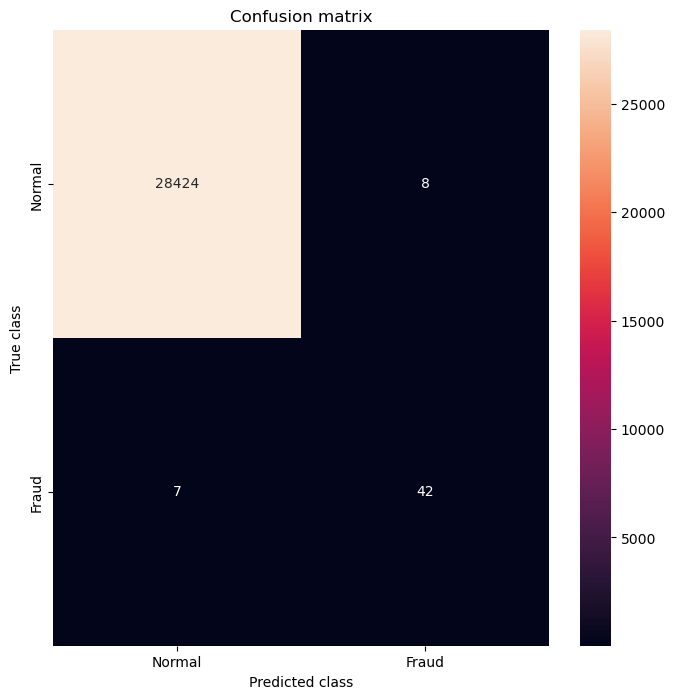

In [19]:


LABELS = ["Normal", "Fraud"]

conf_matrix_xgb = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix_xgb, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d")
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

elementos da matrix

In [20]:
conf_matrix_xgb

array([[28424,     8],
       [    7,    42]])

In [21]:
print('True negatives - actually non-fraudulent and correctly classified as non-fraudulent')
print(conf_matrix_xgb[0][0]) #normal 
print('False positives - actually non-fraudulent but incorrectly classified as fraud')
print(conf_matrix_xgb[0][1]) # normal but predicted fraud 
print('False negatives - actually fraud but incorrectly classified as being non-fraudulent')
print(conf_matrix_xgb[1][0]) # fraud but predicted normal 
print('True positives - actually fraud and correctly classified as fraud')
print(conf_matrix_xgb[1][1]) # Fraud 

True negatives - actually non-fraudulent and correctly classified as non-fraudulent
28424
False positives - actually non-fraudulent but incorrectly classified as fraud
8
False negatives - actually fraud but incorrectly classified as being non-fraudulent
7
True positives - actually fraud and correctly classified as fraud
42


In [22]:
cost_tn = 1 # custo correto, por isso R$1
cost_fp = 10
cost_fn = 100 # custo da fraude não detectada.
cost_tp = 1 # custo correto, por isso R$1

In [23]:
total_cost_of_fraud_xgb = (conf_matrix_xgb[0][0] * cost_tn) + (conf_matrix_xgb[0][1] * cost_fp) + (conf_matrix_xgb[1][0] * cost_fn) + (conf_matrix_xgb[1][1] * cost_tp)
total_cost_of_fraud_xgb

29246

In [24]:
print(f'Custo total do processo R$ {total_cost_of_fraud_xgb}, pelo XGBClassifier.')

Custo total do processo R$ 29246, pelo XGBClassifier.


# LogisticRegression

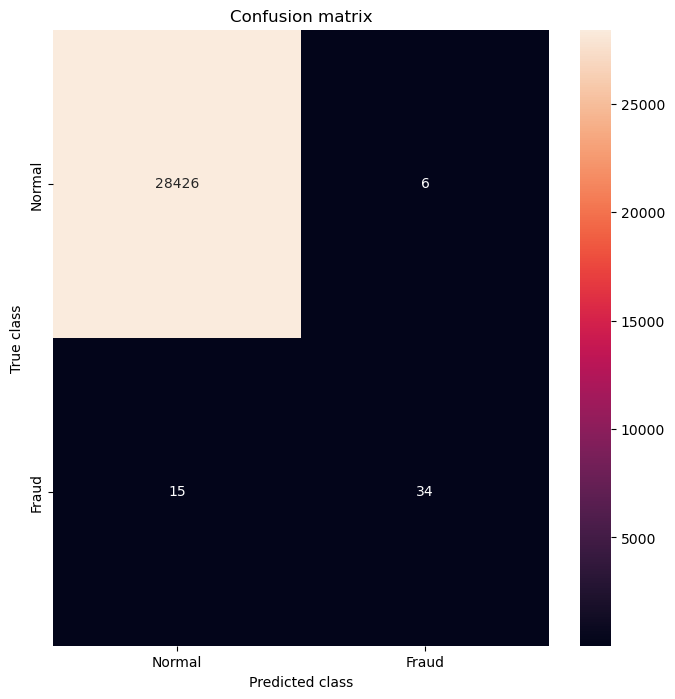

In [25]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression()

model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)

LABELS = ["Normal", "Fraud"]

conf_matrix_lr = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix_lr, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d")
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

In [26]:
total_cost_of_fraud_lr = (conf_matrix_lr[0][0] * cost_tn) + (conf_matrix_lr[0][1] * cost_fp) + (conf_matrix_lr[1][0] * cost_fn) + (conf_matrix_lr[1][1] * cost_tp)
total_cost_of_fraud_lr

30020

In [27]:
print(f'Custo total do processo R$ {total_cost_of_fraud_lr}, pelo LogisticRegression.')

Custo total do processo R$ 30020, pelo LogisticRegression.
